# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

**Dummify** all variables that require this.

In [22]:
! pip install palmerpenguins

In [50]:
import palmerpenguins
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from plotnine import *

In [24]:
penguins_df = palmerpenguins.load_penguins()
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Let's use the other variables to predict `bill_depth_mm`. Prepare your data and fit the following models on the entire dataset:

* Your best multiple linear regression model from before
* Two kNN models (for different values of K)->note, we HAVE to standardize here!
* A decision tree model->don't have to standardize

Create a plot like the right plot of Fig 1. in our `Model Validation` chapter with the training and test error plotted for each of your four models.

Which of your models was best?

In [25]:
#drop NAs
penguins_df = penguins_df.dropna()

In [26]:
#train test split for plot
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(penguins_df.drop(['bill_depth_mm'], axis=1), penguins_df['bill_depth_mm'], test_size=0.25)

In [27]:
#full data for cross validation
X = penguins_df.drop(["bill_depth_mm"], axis = 1)
y = penguins_df["bill_depth_mm"]

In [28]:
X.head()

,species,island,bill_length_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,190.0,3650.0,male,2007


In [29]:
y.head()

,bill_depth_mm
0,18.7
1,17.4
2,18.0
4,19.3
5,20.6


In [30]:
X.dtypes

,0
species,object
island,object
bill_length_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object
year,int64


In [31]:
#define column transformer that dummifies and standardizes variables
ct_dummify_stdz = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore', drop = "first"),
    make_column_selector(dtype_include=object)),
    ("standardize",
    StandardScaler(),
    make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
).set_output(transform = "pandas")

In [32]:
#define column transformer that dummifies variables
ct_dummify = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore', drop = "first"),
    make_column_selector(dtype_include=object))
  ],
  remainder = "passthrough"
).set_output(transform = "pandas")

In [64]:
#define column transformer that passes variable(s) of interest through and dummifies variables
ct_pass_var = ColumnTransformer(
  [
      ("passVar", "passthrough", ["remainder__bill_length_mm"])
  ],
  remainder = "drop" #drop the remaining variables in the data set
).set_output(transform = "pandas")

In [34]:
ct_dummify_stdz.fit_transform(X)

,dummify__species_Chinstrap,dummify__species_Gentoo,dummify__island_Dream,dummify__island_Torgersen,dummify__sex_male,standardize__bill_length_mm,standardize__flipper_length_mm,standardize__body_mass_g,standardize__year
0,0.0,0.0,0.0,1.0,1.0,-0.896042,-1.426752,-0.568475,-1.283742
1,0.0,0.0,0.0,1.0,0.0,-0.822788,-1.069474,-0.506286,-1.283742
2,0.0,0.0,0.0,1.0,0.0,-0.676280,-0.426373,-1.190361,-1.283742
4,0.0,0.0,0.0,1.0,0.0,-1.335566,-0.569284,-0.941606,-1.283742
5,0.0,0.0,0.0,1.0,1.0,-0.859415,-0.783651,-0.692852,-1.283742
...,...,...,...,...,...,...,...,...,...
339,1.0,0.0,1.0,0.0,1.0,2.162314,0.431094,-0.257532,1.180155
340,1.0,0.0,1.0,0.0,0.0,-0.090248,0.073816,-1.003795,1.180155
341,1.0,0.0,1.0,0.0,1.0,1.026876,-0.569284,-0.537380,1.180155
342,1.0,0.0,1.0,0.0,1.0,1.246638,0.645461,-0.133155,1.180155


In [66]:
ct_dummify.fit_transform(X)

,dummify__species_Chinstrap,dummify__species_Gentoo,dummify__island_Dream,dummify__island_Torgersen,dummify__sex_male,remainder__bill_length_mm,remainder__flipper_length_mm,remainder__body_mass_g,remainder__year
0,0.0,0.0,0.0,1.0,1.0,39.1,181.0,3750.0,2007
1,0.0,0.0,0.0,1.0,0.0,39.5,186.0,3800.0,2007
2,0.0,0.0,0.0,1.0,0.0,40.3,195.0,3250.0,2007
4,0.0,0.0,0.0,1.0,0.0,36.7,193.0,3450.0,2007
5,0.0,0.0,0.0,1.0,1.0,39.3,190.0,3650.0,2007
...,...,...,...,...,...,...,...,...,...
339,1.0,0.0,1.0,0.0,1.0,55.8,207.0,4000.0,2009
340,1.0,0.0,1.0,0.0,0.0,43.5,202.0,3400.0,2009
341,1.0,0.0,1.0,0.0,1.0,49.6,193.0,3775.0,2009
342,1.0,0.0,1.0,0.0,1.0,50.8,210.0,4100.0,2009


In [70]:
#best linear regression model
lr_pipeline = Pipeline(
    [("preprocessing", ct_dummify),
    ("linear_regression", LinearRegression())]
)

lr_pipeline_fitted = lr_pipeline.fit(X_train[['bill_length_mm', 'sex', 'flipper_length_mm', 'body_mass_g']], y_train)

#train RMSE
y_lr_train = lr_pipeline_fitted.predict(X_train[['bill_length_mm', 'sex', 'flipper_length_mm', 'body_mass_g']])
rmse_lr_train = root_mean_squared_error(y_train, y_lr_train)

#test RMSE
y_lr_test = lr_pipeline_fitted.predict(X_test[['bill_length_mm', 'sex', 'flipper_length_mm', 'body_mass_g']])
rmse_lr_test = root_mean_squared_error(y_test, y_lr_test)

print(rmse_lr_train)
print(rmse_lr_test)

1.1249605110484329
1.222881719339704


In [53]:
#kNN model selection
kNN_pipeline = Pipeline(
          [("preprocessing", ct_dummify_stdz),
          ("kNN", KNeighborsRegressor())]
)

n_neighbors = {'kNN__n_neighbors': np.array(range(1,100+1,1))}

gscv = GridSearchCV(kNN_pipeline, param_grid = n_neighbors, cv = 5, scoring='r2')
gscv_fitted = gscv.fit(X, y)

In [54]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_[["param_kNN__n_neighbors", "mean_test_score"]].sort_values("mean_test_score", ascending = False)

,param_kNN__n_neighbors,mean_test_score
2,3,0.142194
3,4,0.136600
5,6,0.133619
6,7,0.110906
7,8,0.109950
...,...,...
95,96,-1.463995
96,97,-1.475209
97,98,-1.484027
98,99,-1.502091


It looks like the best two performing models are the ones with k = 3 and k = 4 Let's redefine our pipelines and fit these models on the full data set.

In [40]:
kNN_final_pipeline1 = Pipeline(
          [("preprocessing", ct_dummify_stdz),
          ("kNN", KNeighborsRegressor(n_neighbors=3))]
)

kNN_final_pipeline1_fitted = kNN_final_pipeline1.fit(X_train, y_train)

y_preds_kNN1_train = kNN_final_pipeline1_fitted.predict(X_train)
y_preds_kNN1_test = kNN_final_pipeline1_fitted.predict(X_test)

#train error
rmse_kNN1_train = root_mean_squared_error(y_train, y_preds_kNN1_train)

#test error
rmse_kNN1_test = root_mean_squared_error(y_test, y_preds_kNN1_test)

print(rmse_kNN1_train)
print(rmse_kNN1_test)

0.6612058811850506
0.8401231328245151


In [41]:
kNN_final_pipeline2 = Pipeline(
          [("preprocessing", ct_dummify_stdz),
          ("kNN", KNeighborsRegressor(n_neighbors=4))]
)

kNN_final_pipeline2_fitted = kNN_final_pipeline2.fit(X_train, y_train)

y_preds_kNN2_train = kNN_final_pipeline2_fitted.predict(X_train)
y_preds_kNN2_test = kNN_final_pipeline2_fitted.predict(X_test)

#train error
rmse_kNN2_train = root_mean_squared_error(y_train, y_preds_kNN2_train)

#test error
rmse_kNN2_test = root_mean_squared_error(y_test, y_preds_kNN2_test)

print(rmse_kNN2_train)
print(rmse_kNN2_test)

0.6882822311514918
0.8180715564231353


In [42]:
#decision tree
dt_pipeline = Pipeline(
  [("dummify", ct_dummify),
  ("decision_tree", DecisionTreeRegressor(max_depth=2))]
)

dt_pipeline

Pipeline(steps=[('dummify',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e3c7179f9e0>)])),
                ('decision_tree', DecisionTreeRegressor(max_depth=2))])

In [43]:
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('dummify',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e3c7179f9e0>)])),
                ('decision_tree', DecisionTreeRegressor(max_depth=2))])

In [44]:
#predict y for training data and calculate error
y_dt1_train = dt_pipeline.predict(X=X_train)

#train error
rmse_dt1_train = root_mean_squared_error(y_train, y_dt1_train)
rmse_dt1_train


0.826323242742647

In [45]:
#predict y for test data and calculate error
y_dt1_test = dt_pipeline.predict(X=X_test)

#test error
rmse_dt1_test = root_mean_squared_error(y_test, y_dt1_test)

print(rmse_dt1_test)

0.8463008610675912


[Text(0.5, 0.8333333333333334, 'dummify__species_Gentoo <= 0.5\nsquared_error = 3.831\nsamples = 249\nvalue = 17.188'),
 Text(0.25, 0.5, 'dummify__sex_male <= 0.5\nsquared_error = 1.322\nsamples = 157\nvalue = 18.437'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.834\nsamples = 77\nvalue = 17.726'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.836\nsamples = 80\nvalue = 19.121'),
 Text(0.75, 0.5, 'dummify__sex_male <= 0.5\nsquared_error = 0.902\nsamples = 92\nvalue = 15.055'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.263\nsamples = 43\nvalue = 14.316'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.562\nsamples = 49\nvalue = 15.704')]

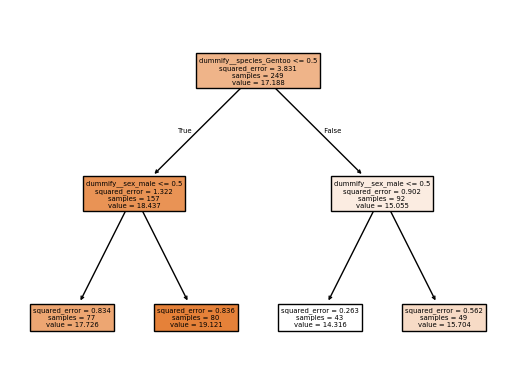

In [46]:
from sklearn.tree import plot_tree

# Access the Decision Tree estimator by its name in the pipeline
decision_tree_estimator = dt_pipeline.named_steps['decision_tree']

feat_names = dt_pipeline.named_steps["dummify"].get_feature_names_out(
    input_features=getattr(X_train, "columns", None)
)


# Plot the decision tree
plot_tree(decision_tree_estimator, feature_names=feat_names, filled = True)

In [72]:
error_df = {'Model': ["linear","kNN1", "kNN2", "dt"], 'Train RMSE': [rmse_lr_train, rmse_kNN1_train, rmse_kNN1_train, rmse_dt1_train], 'Test RMSE': [rmse_lr_test, rmse_kNN1_test, rmse_kNN2_test, rmse_dt1_test]}

error_df = pd.DataFrame(error_df)
error_df

,Model,Train RMSE,Test RMSE
0,linear,1.124961,1.222882
1,kNN1,0.661206,0.840123
2,kNN2,0.661206,0.818072
3,dt,0.826323,0.846301


In [73]:
#plot train vs. test error
error_df_long = error_df[["Model", "Train RMSE", "Test RMSE"]].melt(id_vars=["Model"], value_name = "RMSE", var_name = "type")
error_df_long

,Model,type,RMSE
0,linear,Train RMSE,1.124961
1,kNN1,Train RMSE,0.661206
2,kNN2,Train RMSE,0.661206
3,dt,Train RMSE,0.826323
4,linear,Test RMSE,1.222882
5,kNN1,Test RMSE,0.840123
6,kNN2,Test RMSE,0.818072
7,dt,Test RMSE,0.846301


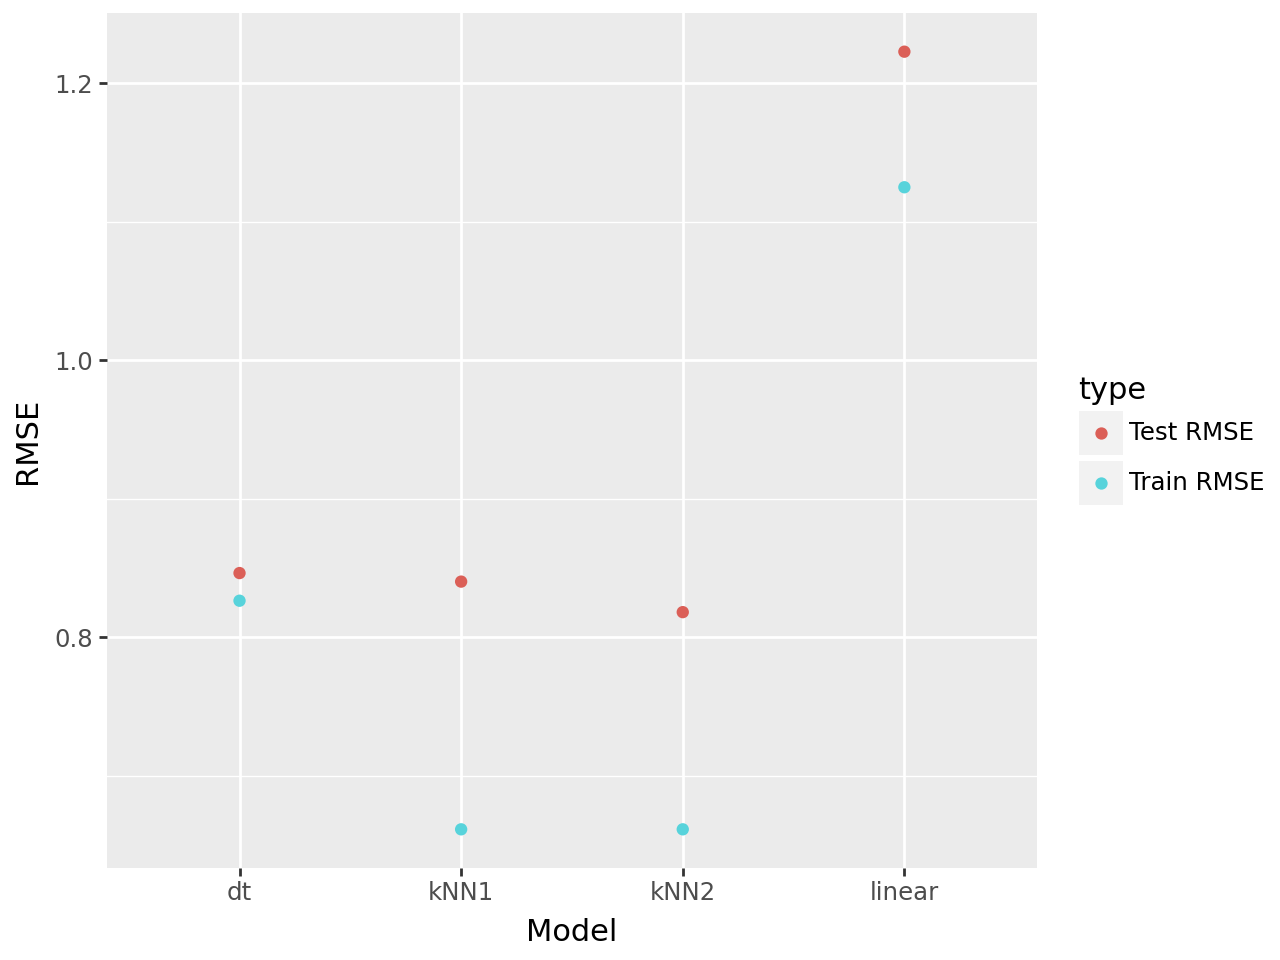

In [74]:
(ggplot(error_df_long,
        aes(x = "Model",
            y = "RMSE",
            color = "type"))
+ geom_point()
)

It appears that the model that performs the best in predicting bill depth is the decision tree model with species and sex as nodes/predictors due to having one of the smallest test RMSE values and close values of test and train RMSE (meaning the model does not overfit the training data and still performs well in terms of predictive power on the test data).